## Data Loading

## In this step, we load the Telco Customer Churn dataset from the local directory using Pandas.

- The dataset is stored in `.xlsx` format.
- This dataset contains customer demographics, services, billing, and churn information.

## This forms the base for all further preprocessing and analysis.

## 🔍 Initial Data Exploration

##We display the first few rows of the dataset to understand:

- Column names
- Data structure
- Types of variables (categorical/numerical)

#This helps in identifying preprocessing steps required later.

In [5]:
import pandas as pd

df = pd.read_excel("../data/raw/churn_data.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 📊 Dataset Understanding

The dataset includes key features such as:

- Customer demographics (Gender, Senior Citizen)
- Subscription details (Contract, Internet Service)
- Billing information (Monthly Charges, Total Charges)
- Target variable: **Churn**

# Goal: Predict whether a customer will churn or not.

In [6]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

## 🧹 Data Cleaning

In this step, we prepare the dataset by:

- Handling missing values
- Fixing incorrect data types
- Removing unnecessary columns (e.g., IDs, location fields if not needed)

Clean data ensures better model performance.

In [7]:
# Drop useless columns
df.drop(columns=[
    'CustomerID', 'Count', 'Country', 'State', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason'
], inplace=True)

In [8]:
# Convert Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [9]:
# Drop nulls (after conversion)
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   object 
 1   Gender             7032 non-null   object 
 2   Senior Citizen     7032 non-null   object 
 3   Partner            7032 non-null   object 
 4   Dependents         7032 non-null   object 
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   object 
 7   Multiple Lines     7032 non-null   object 
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

## ⚙️ Feature Engineering

We create and transform features to improve model performance:

- Convert categorical variables into numerical format
- Create new features like:
  - CLTV (Customer Lifetime Value)
  - MRR (Monthly Recurring Revenue)
  - ARR (Annual Revenue)

This helps the model capture business insights better.

In [11]:
# MRR (Monthly Recurring Revenue)
df['MRR'] = df['Monthly Charges']

# ARR (Annual Recurring Revenue)
df['ARR'] = df['MRR'] * 12

# CLV (recalculate properly)
df['CLV_new'] = df['Monthly Charges'] * df['Tenure Months']

In [12]:
df[['MRR','ARR','CLV_new']].head()

,MRR,ARR,CLV_new
0,53.85,646.2,107.7
1,70.70,848.4,141.4
2,99.65,1195.8,797.2
3,104.80,1257.6,2934.4
4,103.70,1244.4,5081.3


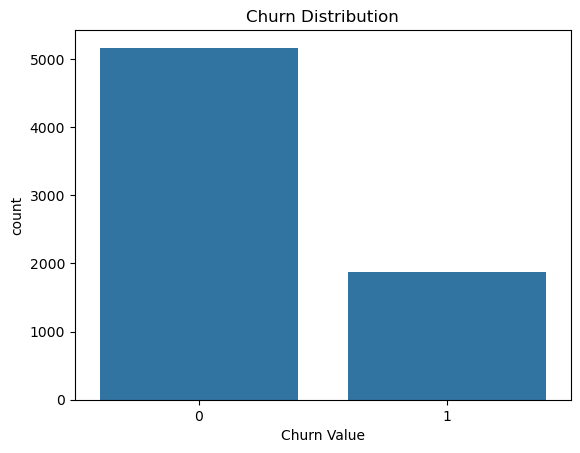

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn Value', data=df)
plt.title("Churn Distribution")
plt.show()

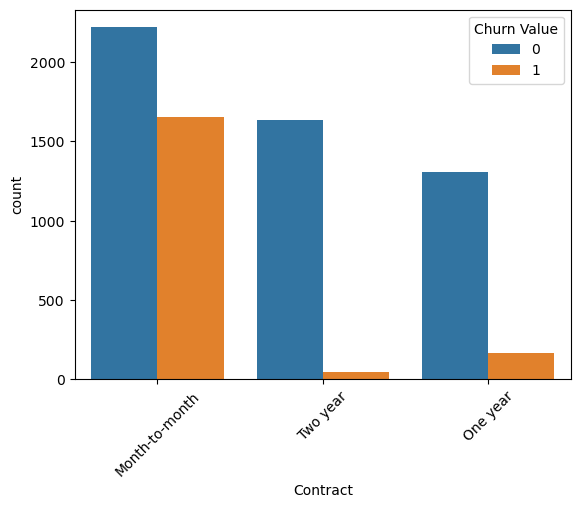

In [14]:
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.xticks(rotation=45)
plt.show()

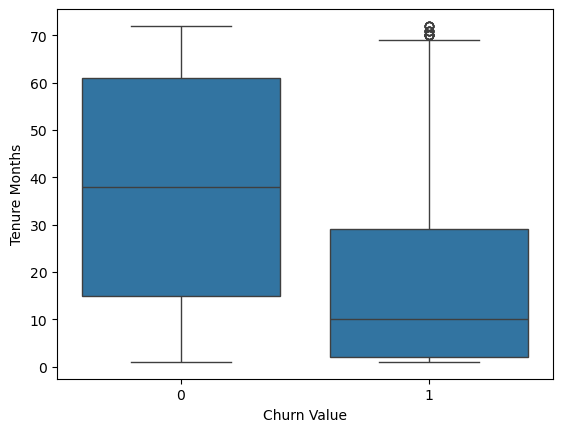

In [15]:
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.show()

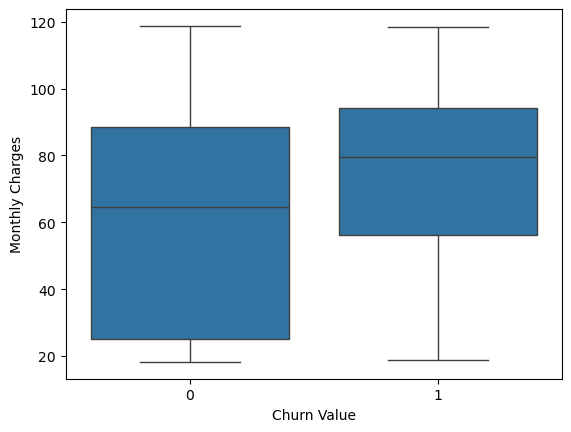

In [16]:
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.show()

## 🔄 Encoding Categorical Variables

Categorical variables are converted into numerical form using:

- One-hot encoding

This allows machine learning models to process non-numeric data effectively.

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [26]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV,MRR,ARR,CLV_new,Gender_Male,Senior Citizen_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,3239,53.85,646.2,107.7,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,2701,70.70,848.4,141.4,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,5372,99.65,1195.8,797.2,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,5003,104.80,1257.6,2934.4,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,5340,103.70,1244.4,5081.3,True,False,...,False,True,False,True,False,False,True,False,False,False


In [27]:
X = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

In [28]:
X.shape

(7032, 34)

In [29]:
y.shape

(7032,)

In [24]:
df = df.drop(columns=['City'])

## ✂️ Train-Test Split

The dataset is split into:

- Training set (for model learning)
- Testing set (for evaluation)

This ensures the model is evaluated on unseen data.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
X_train.shape

(5625, 34)

In [33]:
X_test.shape

(1407, 34)

## 🤖 Model Building

We train machine learning models such as:

- Logistic Regression
- Random Forest Classifier

These models are used to predict customer churn.

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [41]:
y_pred = model.predict(X_test_scaled)

## 📈 Model Evaluation

We evaluate model performance using:

- Accuracy
- Confusion Matrix
- Precision, Recall, F1-score

This helps understand how well the model predicts churn.

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8130774697938877

Confusion Matrix:
 [[914  98]
 [165 230]]

Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.64       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.76      1407
weighted avg       0.81      0.81      0.81      1407



In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
y_pred_rf = rf.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReport:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.798862828713575

Confusion Matrix:
 [[921  91]
 [192 203]]

Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1012
           1       0.69      0.51      0.59       395

    accuracy                           0.80      1407
   macro avg       0.76      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## ⭐ Feature Importance

Using Random Forest, we identify the most important features influencing churn.

#Key insights:
- Tenure
- Monthly Charges
- Contract Type

These factors strongly impact customer churn behavior.

In [47]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

Tenure Months                   0.111487
Total Charges                   0.101810
CLV_new                         0.097322
CLTV                            0.078594
ARR                             0.075094
Monthly Charges                 0.074383
MRR                             0.073724
Contract_Two year               0.046530
Dependents_Yes                  0.040832
Internet Service_Fiber optic    0.039525
dtype: float64

In [48]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [49]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

y_pred_custom = (y_prob > 0.3).astype(int)

In [50]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.58      0.72      1012
           1       0.47      0.93      0.62       395

    accuracy                           0.68      1407
   macro avg       0.71      0.76      0.67      1407
weighted avg       0.82      0.68      0.69      1407



In [52]:
X_scaled = scaler.transform(X)

In [53]:
df['Churn Prediction'] = (model.predict_proba(X_scaled)[:,1] > 0.3).astype(int)

df['Churn Probability'] = model.predict_proba(X_scaled)[:,1]

## 🔮 Churn Prediction

We generate churn probabilities for each customer:

- Probability > 0.7 → High Risk
- 0.4–0.7 → Medium Risk
- < 0.4 → Low Risk

This helps in identifying customers likely to churn.

In [54]:
df[['Churn Value','Churn Prediction','Churn Probability']].head()

,Churn Value,Churn Prediction,Churn Probability
0,1,1,0.597070
1,1,1,0.589878
2,1,1,0.666472
3,1,1,0.556632
4,1,1,0.313949


In [56]:
df.to_csv("../data/processed/processed_churn_data.csv", index=False)

## 💡 Business Insights

Key observations from analysis:

- Customers with month-to-month contracts show higher churn.
- Customers with low tenure are more likely to leave.
- Higher monthly charges increase churn risk.

These insights can help in designing retention strategies.